# Assignment 1

In [81]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, ConfusionMatrixDisplay

In [29]:
#has 3 inputs --- easier dataset linearly seperable
blobs = pd.read_csv("blobs600.csv")
x_blobs = blobs.iloc[:, :-1]
y_blobs = blobs.iloc[:, -1]
print("blobs inputs length: " ,len(x_blobs))
print("blobs outputs length: " ,len(y_blobs))

#has 2 inputs 
circles = pd.read_csv("circles500.csv")
x_circles = circles.iloc[:, :-1]
y_circles = circles.iloc[:, -1]
print("circles inputs length: " , len(x_circles))
print("circles outputs length: " ,len(y_circles))

blobs inputs length:  600
blobs outputs length:  600
circles inputs length:  500
circles outputs length:  500


In [3]:
#better readablity used in multiple sections
def logReg(z):
    return 1 / ( 1 + (math.e)**(-z) )

def lossfunction(y, y_hat):
    return -( (y * math.log(y_hat)) + ((1-y) * math.log(1-y_hat)) )

In [4]:
circles

,X0,X1,Class
0,0.180647,0.552945,1
1,-0.188674,0.325629,1
2,0.413742,0.931251,0
3,-0.199223,0.902665,0
4,0.488279,-0.341202,1
...,...,...,...
495,0.532217,-0.008352,1
496,-0.143676,0.854655,0
497,-0.416100,-0.242321,1
498,0.936010,-0.337975,0


## Task 1

Implement a Nueral Networks based approach to Lgoistic regression

In [41]:

# version 1 calculation of only a single y_hat, (like in slides from lecture) 
def LogRegNN( X, Y):
    #set up for logistic regression
    alpha = 0.05
    max_iters = 100000
    threshold = 0.01
    N = X.shape[0]

    y_output = [] 

    #weights and bias
    #random generation
    weights = [0] * X.shape[1]
    for i,_ in enumerate(weights):
        weights[i] = np.random.uniform(0,0.01)
    #print("weights: ", weights)

    bias=np.random.uniform(0,0.01)

    #stopping criteria
    going = True
    J_running = 0
    J_running_prev=0
    iteration = 0

    while(going):
        chosenIndex = np.random.randint(0,len(X))

        xi = X.iloc[chosenIndex]
        yi = Y.iloc[chosenIndex]

        z = np.dot(weights, xi) + bias
        y_hat = logReg(z)
        
        #J_current is the loss function
        J_current = lossfunction(yi, y_hat)

        #gradient descent ========================================
        deltaW = [0] * X.shape[1]
        deltaB = 0

        #delta loop
        for j,_ in enumerate(weights):
            deltaW[j] = (y_hat - yi) * xi.iloc[j]

        deltaB = y_hat - yi
            
        #actual update loop 
        for j,_ in enumerate(weights):
            weights[j] = weights[j] - (alpha * deltaW[j])

        bias = bias - (alpha * deltaB) 
            
        
        #stopping criterai
        iteration +=1
        if(iteration > max_iters):
            going = False

        J_running += J_current
        
        if (iteration%N == 0):
            if (abs(J_running - J_running_prev) < threshold):
                going = False
            print(J_running, " for iteration ", iteration)
            J_running_prev = J_running
            J_running = 0;

    print("===================================================================================")
    print(weights)
    print(bias)
    print("===================================================================================")
    
    # finalise output
    # predict values
    #using final wieghgts and bias
    X = np.array(X)

    for row in X:
        z = np.dot(row, weights) + bias
        y_hat = logReg(z)
        print(y_hat)
        if y_hat < 0.5:
            y_output.append(0)
        else:
            y_output.append(1)
        

    return y_output #reutrn all the 1s and 0s

    print("iters: " , iteration)
    #print("final chosen index: ",chosenIndex)
    #print("final z: ", z)
    #print("final Y_hat: ", y_hat)
    #print("final y at chosen location: ", Y.iloc[chosenIndex])
    #print("final loss func: ",lossfunction(Y.iloc[chosenIndex], y_hat))
    #print(len(predictedOut))
    #print("circles: ", x_circles.iloc[499])
    #print("function values: " ,function)
    #print(predictedOut)

LogRegNN(x_blobs, y_blobs)

45.62360088664993  for iteration  600
18.15804259124724  for iteration  1200
12.91868436120609  for iteration  1800
15.586719421415653  for iteration  2400
8.842295644846567  for iteration  3000
8.914139256027868  for iteration  3600
6.15649613557574  for iteration  4200
8.625367071044517  for iteration  4800
9.192448053501312  for iteration  5400
6.800598733595357  for iteration  6000
8.516556164091355  for iteration  6600
10.83402238398275  for iteration  7200
9.593814676710878  for iteration  7800
8.757165582672563  for iteration  8400
5.435609908621889  for iteration  9000
5.645825568228167  for iteration  9600
4.178656896688882  for iteration  10200
6.956238127420381  for iteration  10800
8.660661734151521  for iteration  11400
3.9482307119177547  for iteration  12000
6.097216361655409  for iteration  12600
9.00056008003218  for iteration  13200
7.23287803842168  for iteration  13800
5.248017542477175  for iteration  14400
7.256412970960474  for iteration  15000
10.646778782967987

[0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,


## Task 2

need to actually predict, best to make a class so weights can be saved

In [82]:
class LogRegNNet:
    
    #setup params for model
    def __init__(self,alpha, max_iters, threshold):
        self.alpha = alpha
        self.max_iters = max_iters
        self.threshold = threshold
        self.weights = 0
        self.bias = 0
        
         
         
    # here we will train on out data
    # outputs will be the weights and bias
    # so that they can be used later for prediction
    def train(self, X, Y):
        #X and Y here are they training data
        N = X.shape[0] # number amount of data (i.e gives every point the chance to be hit in sgd, could theortically hit all datapoints)

        #weights and bias
        #random generation
        weights = [0] * X.shape[1]
        for i,_ in enumerate(weights):
            weights[i] = np.random.uniform(0,0.01)
        
        bias=np.random.uniform(0,0.01)

        #stopping criteria
        going = True
        J_running = 0
        J_running_prev=0
        iteration = 0

        while(going):
            chosenIndex = np.random.randint(0,len(X))

            xi = X.iloc[chosenIndex]
            yi = Y.iloc[chosenIndex]

            z = np.dot(weights, xi) + bias
            y_hat = logReg(z)
        
            #J_current is the loss function
            J_current = lossfunction(yi, y_hat)

            #gradient descent ========================================
            deltaW = [0] * X.shape[1]
            deltaB = 0

            #delta loop
            for j,_ in enumerate(weights):
                deltaW[j] = (y_hat - yi) * xi.iloc[j]

            deltaB = y_hat - yi
            
                #actual update loop 
            for j,_ in enumerate(weights):
                weights[j] = weights[j] - (self.alpha * deltaW[j])

            bias = bias - (self.alpha * deltaB) 
            
        
                #stopping criterai
            iteration +=1
            if(iteration > self.max_iters):
                going = False

            J_running += J_current
        
            if (iteration%N == 0):
                if (abs(J_running - J_running_prev) < self.threshold):
                    going = False
                    print("iterations total: " ,iteration)
                #print(J_running, " for iteration ", iteration)
                J_running_prev = J_running
                J_running = 0;

            self.weights = weights
            self.bias = bias
        
        return weights, bias

        #here we precit a new set of inputs using the weights and biases from training
    def predict(self, X):
        #x validaiton and x test

        y_output = [] 

        X = np.array(X)
        for row in X:
            z = np.dot(row, self.weights) + self.bias
            y_hat = logReg(z)
            #print(y_hat)
            if y_hat < 0.5:
                y_output.append(0)
            else:
                y_output.append(1)

        return y_output   

### training and testing - blobs

In [109]:
# train = 70%
# test = 15%
# validaiton = 15%
X_train, X_temp, y_train, y_temp = train_test_split(x_blobs, y_blobs, test_size=0.3, random_state=39)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=39)

print("train size: ", len(X_train))
print("Val size: ", len(X_val))
print("test size: ", len(X_test))

train size:  420
Val size:  90
test size:  90


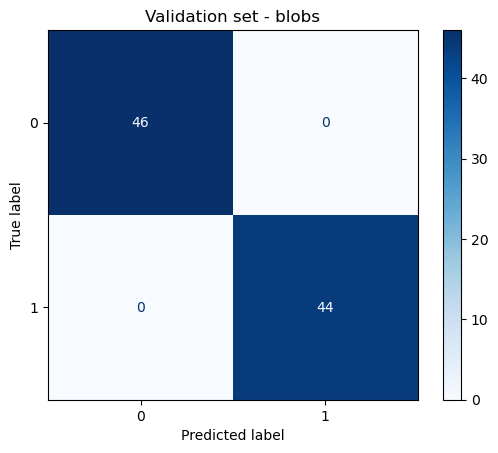


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        44

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [110]:
model = LogRegNNet(0.05,10000,0.01)
model.train(X_train, y_train)
predictions = model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
cm = confusion_matrix(y_val, predictions)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val, predictions, target_names=["0", "1"]))

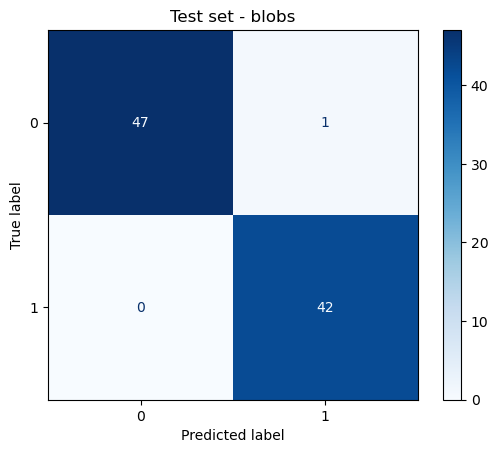


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9888888888888889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.98      1.00      0.99        42

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



In [111]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test, predictions, target_names=["0", "1"]))

### Grpahing test Blobs predictions

In [112]:
print(f"The dimensions of the dataset are: {np.shape(X_test)}")

The dimensions of the dataset are: (90, 3)


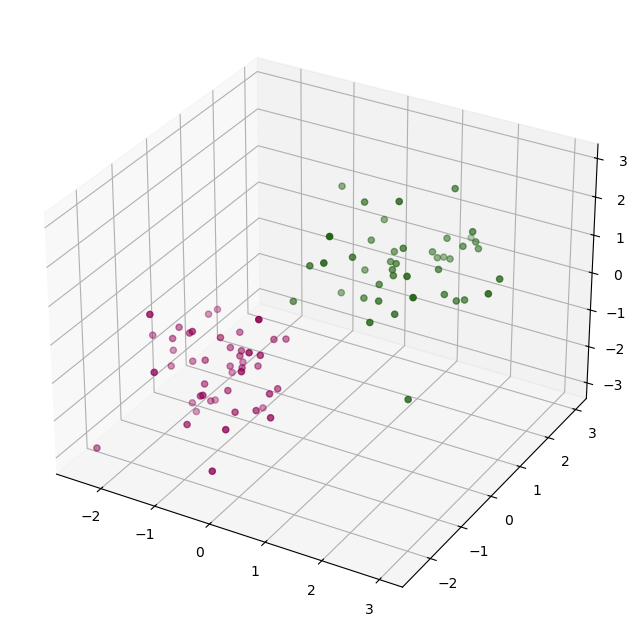

In [115]:
# code form "load-small-datasets"
X_test = X_test.values
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_test[:,0], X_test[:,1], X_test[:,2], c=predictions, cmap="PiYG") 

plt.show()
plt.close(fig)

### training and testing - circles

In [119]:
# train = 70%
# test = 15%
# validaiton = 15%
X_train, X_temp, y_train, y_temp = train_test_split(x_circles, y_circles, test_size=0.3, random_state=39)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=39)

print("train size: ", len(X_train))
print("Val size: ", len(X_val))
print("test size: ", len(X_test))

train size:  350
Val size:  75
test size:  75


iterations total:  19950


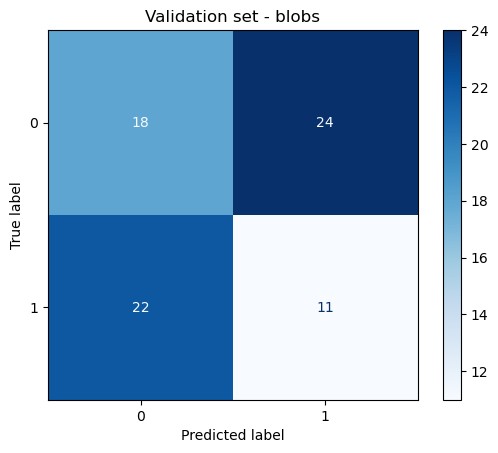


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.38666666666666666
              precision    recall  f1-score   support

           0       0.45      0.43      0.44        42
           1       0.31      0.33      0.32        33

    accuracy                           0.39        75
   macro avg       0.38      0.38      0.38        75
weighted avg       0.39      0.39      0.39        75



In [120]:
model = LogRegNNet(0.05,100000,0.01)
model.train(X_train, y_train)
predictions = model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
cm = confusion_matrix(y_val, predictions)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val, predictions, target_names=["0", "1"]))

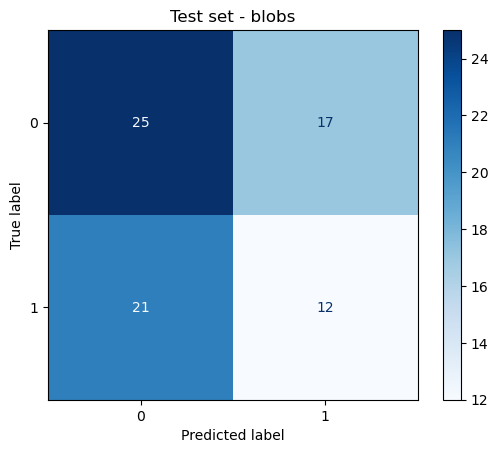


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.49333333333333335
              precision    recall  f1-score   support

           0       0.54      0.60      0.57        42
           1       0.41      0.36      0.39        33

    accuracy                           0.49        75
   macro avg       0.48      0.48      0.48        75
weighted avg       0.49      0.49      0.49        75



In [121]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test, predictions, target_names=["0", "1"]))

### Grpahing test circles predictions

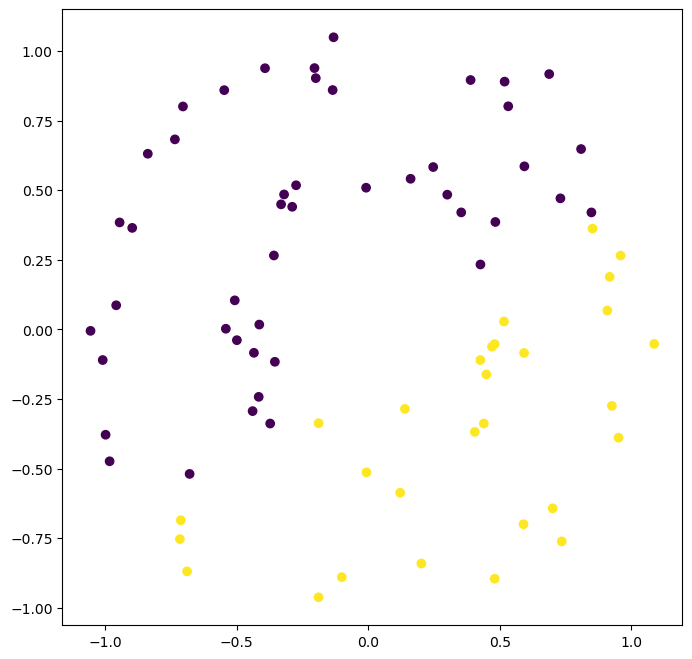

In [123]:
fig, ax = plt.subplots(figsize=(8, 8)) 
X_test = X_test.values
ax.scatter(X_test[:,0], X_test[:,1], c=predictions) 

plt.show()
plt.close(fig)

Here we can see that the blobs dataset is capable of achieving good scores using logistic regression as it is linerly seperable.

on the other hand, using logisitc regression the circles dataset isnt able to score well as it is not linearly seperaeble

## Task 3

## Task 4

## Task 5